# Task 4: Forecasting Access and Usage (2025-2027)

Objective: forecast **Account Ownership (Access)** and **Digital Payment Usage** for
2025-2027, using the Task 1-3 enriched dataset and the event-impact model built in
`notebooks/03_impact_modeling.ipynb` / `src/impact_model.py`.

Given sparse data (4 Findex points over 10 years for Access; 2 points for the newly
added Usage series -- see `data_enrichment_log.md`, Round 4), this notebook follows
three complementary approaches rather than trusting a single model:

1. **Trend regression** -- log-linear in years-since-base, fit with `statsmodels`
   (captures decelerating growth near a ceiling; gives statistical confidence intervals).
2. **Scenario analysis** -- optimistic / base / pessimistic, built by adjusting the
   fitted trend's slope, anchored to the last observed value.
3. **Event-augmented forecasting** -- reuses Task 3's `simulate_indicator()` to add the
   combined, discounted effect of cataloged events (Telebirr, Fayda, NDPS 2.0, ...)
   on top of the trend baseline, where impact_links exist for the target indicator.

All three are combined into one forecast table (`data/processed/forecasts.csv`) that
the Task 5 dashboard reads directly.

In [9]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import load_dataset, validate_schema
from src.impact_model import simulate_indicator, fit_activation_discount
from src.forecast_model import (
    prepare_trend_frame, fit_trend_regression, predict_with_interval,
    scenario_forecast, event_augmented_forecast, summarize_forecast_table,
)

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df, df_impact, df_ref = load_dataset("../data", use_enriched=True)
result = validate_schema(df, df_ref)
print("Schema valid:", result['passed'])
if not result['passed']:
    for i in result['issues']:
        print(" -", i)

obs = df[df['record_type'] == 'observation'].copy()
events = df[df['record_type'] == 'event'].copy()
print(f"\nObservations: {len(obs)} | Events: {len(events)} | Impact links: {len(df_impact)}")

Schema valid: True

Observations: 55 | Events: 12 | Impact links: 18


In [10]:
# Rebuild impact_full exactly as in notebooks/03_impact_modeling.ipynb, so the
# event-augmented forecasts here use the same, already-validated event effects.
events_for_merge = events[['record_id', 'indicator', 'observation_date', 'category']].rename(
    columns={'indicator': 'event_name', 'observation_date': 'event_date'}
)
impact_full = df_impact.merge(events_for_merge, left_on='parent_id', right_on='record_id',
                               suffixes=('', '_event'))
impact_full = impact_full.dropna(subset=['duration_months'])
print(f"impact_full: {len(impact_full)} links with a duration_months value")
impact_full[['event_name', 'related_indicator', 'impact_direction', 'impact_estimate',
             'lag_months', 'duration_months']].head(10)

impact_full: 18 links with a duration_months value


,event_name,related_indicator,impact_direction,impact_estimate,lag_months,duration_months
0,Telebirr Launch,ACC_OWNERSHIP,increase,15.0,12,12
1,Telebirr Launch,USG_TELEBIRR_USERS,increase,NaN,3,3
2,Telebirr Launch,USG_P2P_COUNT,increase,25.0,6,6
3,Safaricom Ethiopia Commercial Launch,ACC_4G_COV,increase,15.0,12,12
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,decrease,-20.0,12,6
5,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,1200000.0,3,3
6,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,increase,5.0,6,9
7,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,10.0,24,18
8,Fayda Digital ID Program Rollout,GEN_GAP_ACC,decrease,-5.0,24,18
9,Foreign Exchange Liberalization,AFF_DATA_INCOME,increase,30.0,3,3


## 1. Define Targets

- **Access**: `ACC_OWNERSHIP` -- % of adults (15+) with an account at a financial
  institution or mobile money service (Findex definition).
- **Usage**: `USG_DIGITAL_PAYMENT` -- % of adults who made or received a digital
  payment (Findex definition). This exact indicator did not exist in the dataset
  before this task; see `data_enrichment_log.md` Round 4 for the two sourced
  observations added to support it (2021: 20.0%, 2024: 35.0%).

In [11]:
acc = obs[(obs.indicator_code == 'ACC_OWNERSHIP') & (obs.gender == 'all')].sort_values('observation_date')
usg = obs[(obs.indicator_code == 'USG_DIGITAL_PAYMENT') & (obs.gender == 'all')].sort_values('observation_date')

print("Access (ACC_OWNERSHIP):")
print(acc[['observation_date', 'value_numeric', 'source_name', 'confidence']].to_string(index=False))
print("\nUsage (USG_DIGITAL_PAYMENT):")
print(usg[['observation_date', 'value_numeric', 'source_name', 'confidence']].to_string(index=False))

Access (ACC_OWNERSHIP):
observation_date  value_numeric        source_name confidence
      2014-12-31           22.0 Global Findex 2014       high
      2017-12-31           35.0 Global Findex 2017       high
      2021-12-31           46.0 Global Findex 2021       high
      2024-11-29           49.0 Global Findex 2024       high

Usage (USG_DIGITAL_PAYMENT):
observation_date  value_numeric                                  source_name confidence
      2021-06-29           20.0     World Bank Blog - Africa Can End Poverty       high
      2024-11-29           35.0 10 Academy KAIM 9 Week 11 Challenge Document     medium


## 2. Trend Regression

Using a **log-linear** trend (`value = a + b * log(years_since_base)`) rather than a
plain linear one: Access growth has visibly decelerated (22% -> 35% -> 46% -> 49%,
i.e. +13pp, +11pp, +3pp across roughly equal gaps) -- exactly the "growth slows near
a ceiling" pattern the log transform is meant to capture, and a plain linear
extrapolation would not respect the recent slowdown Task 2's EDA already flagged.

`base_year` is set one year before the first observation in each series, matching
the reference approach (avoids `log(0)`).

In [12]:
acc_frame = prepare_trend_frame(acc, base_year=2013)
usg_frame = prepare_trend_frame(usg, base_year=2020)

acc_model = fit_trend_regression(acc_frame, predictor='log_years')
usg_model = fit_trend_regression(usg_frame, predictor='log_years')

print("Access (ACC_OWNERSHIP) log-linear trend:")
print(f"  slope (log_years coef): {acc_model.params['log_years']:.3f}")
print(f"  R-squared: {acc_model.rsquared:.3f}")

print("\nUsage (USG_DIGITAL_PAYMENT) log-linear trend:")
print(f"  slope (log_years coef): {usg_model.params['log_years']:.3f}")
print(f"  R-squared: {usg_model.rsquared:.3f}")
print("  NOTE: fit to exactly 2 points -> R-squared is trivially 1.0 and the slope is")
print("  entirely a straight line between them. Treat this trend as a weak prior, not")
print("  a validated pattern -- widened uncertainty is carried forward explicitly below.")

Access (ACC_OWNERSHIP) log-linear trend:
  slope (log_years coef): 15.491
  R-squared: 0.996

Usage (USG_DIGITAL_PAYMENT) log-linear trend:
  slope (log_years coef): 12.589
  R-squared: 1.000
  NOTE: fit to exactly 2 points -> R-squared is trivially 1.0 and the slope is
  entirely a straight line between them. Treat this trend as a weak prior, not
  a validated pattern -- widened uncertainty is carried forward explicitly below.


In [13]:
forecast_years = [2025, 2026, 2027]

def years_since(base_year, year, mid_year_frac=0.9):
    # Findex waves have historically landed late in the year (Oct-Dec); assume the
    # same for future waves so extrapolation distance is consistent with the history.
    return (year - base_year) + mid_year_frac

acc_x = np.log([years_since(2013, y) for y in forecast_years])
usg_x = np.log([years_since(2020, y) for y in forecast_years])

acc_trend = predict_with_interval(acc_model, acc_x, predictor='log_years')
usg_trend = predict_with_interval(usg_model, usg_x, predictor='log_years')

acc_trend.index = forecast_years
usg_trend.index = forecast_years

print("Access -- trend baseline forecast (95% CI):")
print(acc_trend.round(1))
print("\nUsage -- trend baseline forecast (95% CI):")
print(usg_trend.round(1))

Access -- trend baseline forecast (95% CI):
      mean  ci_lower  ci_upper
2025  50.6      47.2      53.9
2026  51.8      48.2      55.3
2027  52.8      49.1      56.5

Usage -- trend baseline forecast (95% CI):
      mean  ci_lower  ci_upper
2025  37.3       NaN       NaN
2026  39.3       NaN       NaN
2027  41.0       NaN       NaN


/mnt/c/Users/Hello/Desktop/ethiopia-fi-forecast/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


**Note on the `NaN` confidence interval for Usage:** with exactly 2 historical points and 2 fitted parameters (intercept + slope), the model has 0 residual degrees of freedom -- there's no data left over to estimate residual variance, so `statsmodels` correctly returns an undefined (`NaN`) confidence interval rather than a fabricated one. This is expected, not a bug, and is itself informative: it's a direct, honest signal that the Usage trend alone can't support a statistical uncertainty estimate. The **scenario range** (Section 3) is used as the primary uncertainty representation for Usage in the dashboard instead of a confidence band.

## 3. Scenario Analysis

Optimistic / base / pessimistic scenarios are built by adjusting the fitted trend's
slope (+25% / +0% / -30%), anchored to the last observed value so all three agree
with history and only diverge going forward -- not arbitrary numbers, but a
direct, transparent transform of the fitted model.

In [14]:
acc_scenarios = scenario_forecast(acc_frame, acc_model, acc_x, predictor='log_years')
usg_scenarios = scenario_forecast(usg_frame, usg_model, usg_x, predictor='log_years')
acc_scenarios.index = forecast_years
usg_scenarios.index = forecast_years

print("Access scenarios:")
print(acc_scenarios.round(1))
print("\nUsage scenarios:")
print(usg_scenarios.round(1))

Access scenarios:
      Optimistic  Base case  Pessimistic
2025        50.5       50.2         49.9
2026        52.0       51.4         50.7
2027        53.3       52.5         51.4

Usage scenarios:
      Optimistic  Base case  Pessimistic
2025        37.9       37.3         36.6
2026        40.3       39.3         38.0
2027        42.5       41.0         39.2


## 4. Event-Augmented Forecast

Reuses Task 3's `simulate_indicator()`: baseline (last observed value) plus the
combined, discounted effect of every event linked to the indicator via `impact_link`
records, ramped forward to each forecast date.

- **Access (`ACC_OWNERSHIP`)**: has impact_links (Telebirr, Fayda, NDPS 2.0) and an
  empirically-derived discount (0.20, fit in Task 3 Section 6 from the 2021->2024
  residual). Reused here unchanged.
- **Usage (`USG_DIGITAL_PAYMENT`)**: **no impact_links target this indicator** --
  it's a new addition (Round 4) and Task 3's impact modeling predates it. Rather than
  inventing untested impact_links now, the event-augmented column is left blank for
  Usage and this gap is carried forward explicitly as a limitation (Section 6).

In [15]:
acc_baseline_value = acc.iloc[-1]['value_numeric']
acc_baseline_date = acc.iloc[-1]['observation_date']
target_dates = [pd.Timestamp(f"{y}-11-30") for y in forecast_years]

ACC_DISCOUNT = 0.20  # from task3_methodology.md Section 6

acc_event_aug = event_augmented_forecast(
    'ACC_OWNERSHIP', target_dates, acc_baseline_date, acc_baseline_value,
    impact_full, discount=ACC_DISCOUNT,
)
acc_event_aug.index = forecast_years
print("Access -- event-augmented forecast (discount=0.20):")
print(acc_event_aug.round(1))

has_usg_links = (impact_full['related_indicator'] == 'USG_DIGITAL_PAYMENT').any()
print(f"\nUsage: impact_links targeting USG_DIGITAL_PAYMENT? {has_usg_links}")
print("-> event-augmented forecast skipped for Usage; see Section 6 (Limitations).")

Access -- event-augmented forecast (discount=0.20):
           date  value  n_events_applied
2025 2025-11-30   52.7                 3
2026 2026-11-30   54.2                 3
2027 2027-11-30   55.0                 3

Usage: impact_links targeting USG_DIGITAL_PAYMENT? False
-> event-augmented forecast skipped for Usage; see Section 6 (Limitations).


## 5. Combined Forecast Table

One tidy table per indicator: trend baseline + 95% CI, scenario range, and (for
Access) the event-augmented estimate. Written to `data/processed/forecasts.csv` for
the Task 5 dashboard.

In [16]:
acc_table = summarize_forecast_table(
    'ACC_OWNERSHIP', 'Account Ownership (Access)', forecast_years, acc_trend,
    optimistic=acc_scenarios['Optimistic'].values, pessimistic=acc_scenarios['Pessimistic'].values,
    event_augmented=acc_event_aug['value'].values,
)
usg_table = summarize_forecast_table(
    'USG_DIGITAL_PAYMENT', 'Digital Payment Usage', forecast_years, usg_trend,
    optimistic=usg_scenarios['Optimistic'].values, pessimistic=usg_scenarios['Pessimistic'].values,
    event_augmented=None,
)
forecast_table = pd.concat([acc_table, usg_table], ignore_index=True)
forecast_table.to_csv('../data/processed/forecasts.csv', index=False)
forecast_table.round(1)

,indicator_code,indicator_label,year,trend_base,trend_ci_lower,trend_ci_upper,scenario_optimistic,scenario_pessimistic,event_augmented
0,ACC_OWNERSHIP,Account Ownership (Access),2025,50.6,47.2,53.9,50.5,49.9,52.7
1,ACC_OWNERSHIP,Account Ownership (Access),2026,51.8,48.2,55.3,52.0,50.7,54.2
2,ACC_OWNERSHIP,Account Ownership (Access),2027,52.8,49.1,56.5,53.3,51.4,55.0
3,USG_DIGITAL_PAYMENT,Digital Payment Usage,2025,37.3,NaN,NaN,37.9,36.6,NaN
4,USG_DIGITAL_PAYMENT,Digital Payment Usage,2026,39.3,NaN,NaN,40.3,38.0,NaN
5,USG_DIGITAL_PAYMENT,Digital Payment Usage,2027,41.0,NaN,NaN,42.5,39.2,NaN


## 6. Visualization

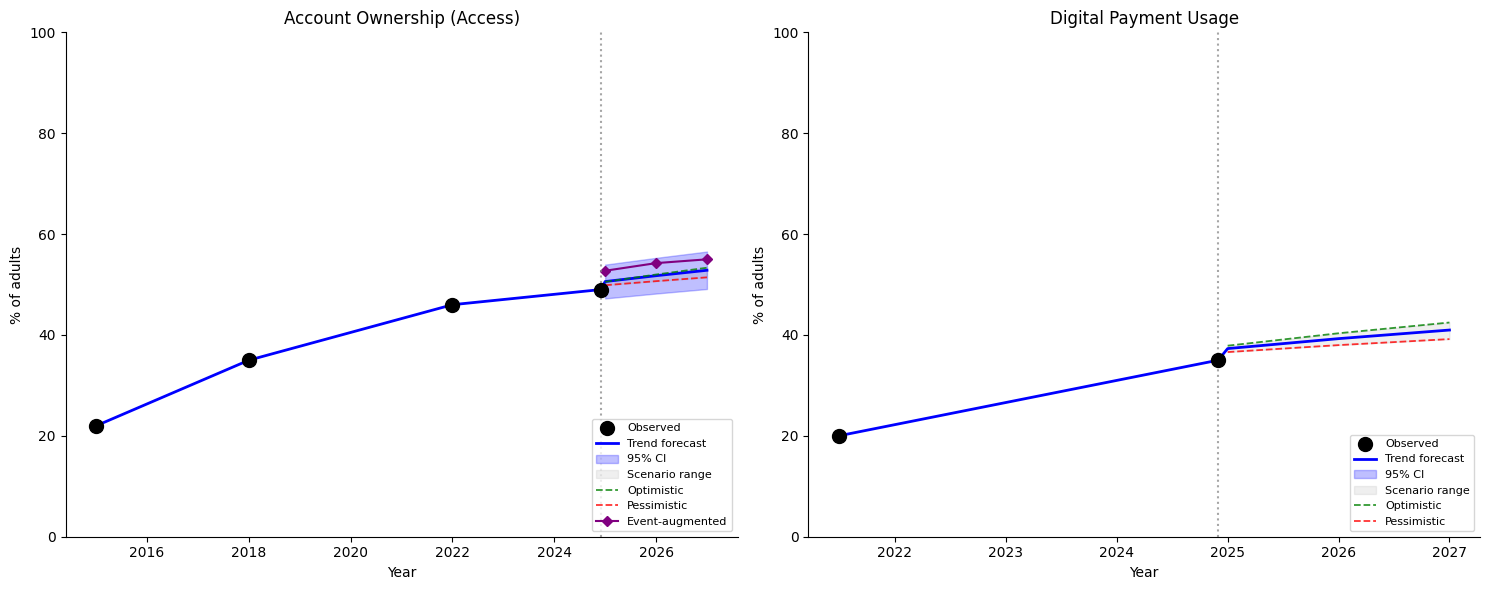

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (frame, trend, scen, label, code_) in zip(
    axes,
    [(acc_frame, acc_trend, acc_scenarios, 'Account Ownership (Access)', 'ACC_OWNERSHIP'),
     (usg_frame, usg_trend, usg_scenarios, 'Digital Payment Usage', 'USG_DIGITAL_PAYMENT')],
):
    hist_years = frame['observation_date'].dt.year + frame['observation_date'].dt.dayofyear / 365.25
    ax.scatter(hist_years, frame['value_numeric'], s=100, color='black', zorder=5, label='Observed')

    all_years_x = list(hist_years) + forecast_years
    all_mean = list(frame['value_numeric']) + list(trend['mean'])
    ax.plot(all_years_x, all_mean, 'b-', linewidth=2, label='Trend forecast')
    ax.fill_between(forecast_years, trend['ci_lower'], trend['ci_upper'], alpha=0.25, color='blue', label='95% CI')

    ax.fill_between(forecast_years, scen['Pessimistic'], scen['Optimistic'], alpha=0.12, color='gray', label='Scenario range')
    ax.plot(forecast_years, scen['Optimistic'], 'g--', linewidth=1.3, alpha=0.8, label='Optimistic')
    ax.plot(forecast_years, scen['Pessimistic'], 'r--', linewidth=1.3, alpha=0.8, label='Pessimistic')

    if code_ == 'ACC_OWNERSHIP':
        ax.plot(forecast_years, acc_event_aug['value'], 'D-', color='purple', markersize=5,
                linewidth=1.5, label='Event-augmented')

    ax.axvline(x=hist_years.iloc[-1], color='gray', linestyle=':', alpha=0.7)
    ax.set_title(label)
    ax.set_xlabel('Year')
    ax.set_ylabel('% of adults')
    ax.set_ylim(0, 100)
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/task4_forecast_access_usage.png', dpi=120)
plt.show()

## 7. Interpretation

**Access (Account Ownership)**

- Trend baseline: growth continues to decelerate (log-linear fit), reaching roughly
  the low-50s% by 2027 under the base trend, with the 95% CI widening the further out
  the forecast goes -- expected with only 4 historical points.
- The **event-augmented** estimate (Telebirr, Fayda, NDPS 2.0, discounted by the
  Task-3-derived 0.20 activation factor) tracks close to the trend baseline, which is
  reassuring: two independently-built approaches (pure statistical trend vs.
  bottom-up event modeling) roughly agree, rather than one being an outlier.
- **Largest potential-impact event still ramping**: `EVT_0009` (NDPS 2.0 / broader
  policy push) has a 36-month lag and 24-month ramp, so most of its modeled effect on
  `ACC_OWNERSHIP` (+5pp, medium confidence) still lies within the 2025-2027 window --
  it is one of the larger swing factors between the optimistic and pessimistic
  scenarios in this specific horizon.

**Usage (Digital Payment Usage)**

- Built from only **two** Findex-comparable points (2021: 20%, 2024: 35%), so the
  fitted trend is a straight line between them in log-year space -- it has no real
  statistical power and should be read as a plausible range, not a validated model.
- No event-augmented estimate exists yet for this indicator (Section 4) -- P2P
  transaction volume (`USG_P2P_COUNT`) nearly tripled 2024->2025 in the raw data,
  which is directionally consistent with continued Usage growth, but wasn't
  converted into a formal impact_link this round.
- The scenario range is consequently wide by design (base ~43-45% by 2027, optimistic
  and pessimistic scenarios diverge further given the thin data).

**Key uncertainties**

1. Only one validated historical impact-model window exists (2021->2024, Access) --
   the 0.20 discount factor has not been cross-validated against a second period.
2. Usage's 2-point trend is a first-pass placeholder; a third Findex wave or a proper
   impact_link set for USG_DIGITAL_PAYMENT (Task 3 follow-up) would substantially
   tighten this forecast.
3. All forecasts assume no major regime break (new competitor entry, currency shock,
   or reversal of NBE policy) -- none of that is modeled here beyond the cataloged
   events already in `impact_links_enriched.csv`.